In [6]:
#문제 1.
#올리브영 간단 크롤링
#1) 상품명 / 브랜드명 / 가격 / 할인률 / 리뷰 수
#2) MySQL 저장
#3) SQL로 분석해야 하는 내용
#- 할인률 상위 5개 상품 조회
#- 브랜드별 평균할인률 및 평균 리뷰 수
#- 리뷰수 대비 가격이 가장 높은 상품 TOP 3

from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from webdriver_manager.chrome import ChromeDriverManager
import time
import re
import pymysql  # MySQL 연결

# --- WebDriver 설정 ---
service = Service(ChromeDriverManager().install())
options = Options()
options.add_argument('--window-size=1920x1080')
options.add_argument('--start-maximized')
options.add_argument('--user-agent=Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/138.0.0.0 Safari/537.36')
options.add_argument('--lang=ko-KR')

driver = webdriver.Chrome(service=service, options=options)

# --- MySQL 연결 ---
conn = pymysql.connect(
    host="localhost",
    user="root",
    password="Wonsil929621!@#",
    database="olive_db",
    port=3306,
    charset="utf8mb4"
)
cursor = conn.cursor()

try:
    driver.get("https://www.oliveyoung.co.kr/")
    time.sleep(2)

    # "랭킹" 클릭
    try:
        driver.find_element(By.LINK_TEXT, "랭킹").click()
    except:
        driver.find_element(By.CSS_SELECTOR, "a[href*='ranking'], a[data-attr*='랭킹']").click()
    time.sleep(2)

    # 스크롤 조금 내려주기
    for _ in range(5):
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(1)

    product_info_list = []

    # -------------------
    # li 태그 안 상품 수집
    # -------------------
    li_products = driver.find_elements(By.CSS_SELECTOR, "li > div.prd_info")
    print(f"li 기준 수집: {len(li_products)}개")

    for p in li_products:
        try:
            brand = p.find_element(By.CSS_SELECTOR, ".prd_name .tx_brand").get_attribute("textContent").strip()
            name  = p.find_element(By.CSS_SELECTOR, ".prd_name .tx_name").get_attribute("textContent").strip()
            price_raw = p.find_element(By.CSS_SELECTOR, ".prd_price .tx_num").get_attribute("textContent").strip()
            price = int(re.sub(r"[^0-9]", "", price_raw))
            product_info_list.append((brand, name, price))
        except Exception as e:
            print("li 파싱 오류:", e)
            continue

    # -------------------
    # ul 태그 안 상품 수집
    # -------------------
    ul_products = driver.find_elements(By.CSS_SELECTOR, "ul.cate_prd_list li > div.prd_info")
    print(f"ul 기준 수집: {len(ul_products)}개")

    for p in ul_products:
        try:
            brand = p.find_element(By.CSS_SELECTOR, ".prd_name .tx_brand").get_attribute("textContent").strip()
            name  = p.find_element(By.CSS_SELECTOR, ".prd_name .tx_name").get_attribute("textContent").strip()
            price_raw = p.find_element(By.CSS_SELECTOR, ".prd_price .tx_num").get_attribute("textContent").strip()
            price = int(re.sub(r"[^0-9]", "", price_raw))
            product_info_list.append((brand, name, price))
        except Exception as e:
            print("ul 파싱 오류:", e)
            continue

    # -------------------
    # DB 저장
    # -------------------
    sql = "INSERT INTO olive_products (brand, name, price) VALUES (%s, %s, %s)"
    cursor.executemany(sql, product_info_list)
    conn.commit()

    print("\n=== DB 저장 완료 ===")
    for item in product_info_list[:10]:  # 샘플 10개 출력
        print(f"{item[0]} : {item[1]} : {item[2]:,}원")

finally:
    if driver:
        driver.quit()
    if cursor:
        cursor.close()
    if conn:
        conn.close()


li 기준 수집: 100개
ul 기준 수집: 100개

=== DB 저장 완료 ===
메디힐 : [8월올영픽/31억장 돌파] 메디힐 에센셜 마스크팩 10/10+1매 7종 택1 : 20,000원
려 : [하루특가/추가증정] 1+1 려 루트젠 탈모증상케어 두피에센스 80ML 더블기획+샴푸50ML : 39,800원
메디힐 : [63관왕/200매] 메디힐 네모패드 100+100매 더블기획 8종 골라담기 : 39,900원
이니스프리 : [8월 올영픽/하트거울증정] 이니스프리 레티놀 시카 흔적 앰플 30ml 더블 기획 : 52,000원
쏘내추럴 : 쏘내추럴 올 데이 메이크업 픽서 더블기획 (120ml+120ml) : 42,000원
토리든 : [8월 올영픽/가나디 콜라보] 토리든 다이브인 저분자 히알루론산 세럼 50ml 리필 가나디 기획 (+인형키링) : 36,000원
비플레인 : [천만돌파/1+1] 비플레인 녹두 약산성 클렌징폼 160ml+160ml 기획 : 26,000원
마녀공장 : [4년연속1위/블랙헤드OUT] 마녀공장 퓨어 클렌징 오일 300ml 기획 (+25mlx2) : 25,000원
유이크 : [스칼렛언니PICK] 유이크 바이옴 베리어 콜라겐 퍼밍 클렌징밤 100ml : 28,000원
리덴스 : [하루 PICK/100%구매이벤트] 리덴스 톤앤스팟 코렉터 앰플 30ml 더블기획 : 39,900원


In [12]:
import pymysql
import pandas as pd

from sqlalchemy import create_engine

#데이터베이스 연결 
host = 'localhost'
user = 'root'
password = 'Wonsil929621!@#'
db_name = 'musinsa_ranking'
charset = 'utf8'
port = 3306 

db = pymysql.connect(
    host = host,
    user= user,
    password = password,
    database = db_name
    
)

cursor = db.cursor()


#데이터베이스 생성 
#cursor = db.cursor()
#sql = "CREATE DATABASE IF NOT EXISTS musinsa_ranking"
#cursor.execute(sql)

#테이블 생성 

sql = """ 
    CREATE TABLE IF NOT EXISTS ranking_products (
    id INT AUTO_INCREMENT PRIMARY KEY,
    product_name VARCHAR(150) NOT NULL,
    brand_name VARCHAR(50) NOT NULL,
    price INT NOT NULL,
    discount_rate INT NOT NULL,
    review_count INT NOT NULL   
    )


"""
cursor.execute(sql)
print("테이블 생성완료")
db.commit()


테이블 생성완료


In [9]:
!pip install xlsxwriter

In [ ]:
#문제 2.
#스타벅스 사이트 > 메뉴 > 음료 > 카테고리(선택) 데이터 기반으로 마케팅 인사이트 도출
#1) 원하는 카테고리 선택 후 음료 페이지 크롤링 (이름, 사진, 용량, 칼로리)
#2) 크롤링 데이터 엑셀 출력
#3) SQL로 분석해야 하는 내용
#- 카테고리별 평균 칼로리
#- 상품금액과 칼로리 상관관계 분석

In [10]:
# 네이버 검색광고 API: 트러블/기초/가성비 화장품 Top100 수집 → Excel(raw+dedup)
import requests, json, time, hmac, hashlib, base64, os
import pandas as pd
from urllib.parse import urlencode

# 🔐 API 인증 (운영에선 환경변수 권장)
NAVER_ADS_ACCESS_LICENSE = "01000000002cea37634b3f192084067ffaaa24e226fbed9899a055a9e1b1322615d04f01f6"
NAVER_ADS_SECRET_KEY     = "AQAAAAAs6jdjSz8ZIIQGf/qqJOImbso08SOHcLbqAHc9Iw/6Ow=="
NAVER_ADS_CUSTOMER_ID    = "3510366"  # 문자열

API_BASE = "https://api.searchad.naver.com"
PATH     = "/keywordstool"
METHOD   = "GET"

SEEDS = ["트러블화장품", "기초화장품", "가성비화장품"]

def make_headers() -> dict:
    ts = str(int(time.time() * 1000))
    msg = f"{ts}.{METHOD}.{PATH}".encode("utf-8")
    sig = base64.b64encode(hmac.new(NAVER_ADS_SECRET_KEY.encode("utf-8"), msg, hashlib.sha256).digest()).decode()
    return {
        "X-Timestamp": ts,
        "X-API-KEY": NAVER_ADS_ACCESS_LICENSE,
        "X-Customer": NAVER_ADS_CUSTOMER_ID,
        "X-Signature": sig
    }

def build_url(base: str, path: str, params: dict) -> str:
    return f"{base}{path}?" + urlencode(params, encoding="utf-8", doseq=True, safe=",")

def to_int(v):
    try:
        return int(str(v))
    except:
        try:
            return int(float(str(v)))
        except:
            return 0

def to_float(v):
    try:
        return float(str(v))
    except:
        return None

def fetch_top100(seed: str) -> list:
    params = {"hintKeywords": seed, "showDetail": 1}
    url = build_url(API_BASE, PATH, params)
    r = requests.get(url, headers=make_headers(), timeout=20)
    r.raise_for_status()
    data = r.json()
    kw_list = data.get("keywordList", [])
    # Mobile 검색량 기준 Top100
    kw_sorted = sorted(kw_list, key=lambda x: to_int(x.get("monthlyMobileQcCnt")), reverse=True)
    return kw_sorted[:100]

def main():
    rows = []
    print("--- 네이버 검색광고 API: 화장품 키워드 Top100 수집 시작 ---")
    for seed in SEEDS:
        print(f"[진행] '{seed}' 요청중 ...")
        top100 = fetch_top100(seed)
        print(f"[결과] '{seed}' {len(top100)}개 수집")
        for it in top100:
            rows.append({
                "seed": seed,
                "relKeyword": it.get("relKeyword"),
                "monthlyPcQcCnt": to_int(it.get("monthlyPcQcCnt")),
                "monthlyMobileQcCnt": to_int(it.get("monthlyMobileQcCnt")),
                "compIdx": to_float(it.get("compIdx")),
                "monthlyAvePcClkCnt": to_float(it.get("monthlyAvePcClkCnt")),
                "monthlyAveMobileClkCnt": to_float(it.get("monthlyAveMobileClkCnt")),
                "monthlyAvePcCtr": to_float(it.get("monthlyAvePcCtr")),
                "monthlyAveMobileCtr": to_float(it.get("monthlyAveMobileCtr")),
                "plAvgDepth": to_float(it.get("plAvgDepth")),
                "compAvgRank": to_float(it.get("compAvgRank")),
            })
        time.sleep(0.2)  # 과도한 연속호출 방지

    if not rows:
        print("수집 결과가 비어 있습니다.")
        return

    df = pd.DataFrame(rows)
    # 총검색량
    df["totalSearch"] = df["monthlyPcQcCnt"] + df["monthlyMobileQcCnt"]
    # 저장 경로
    xlsx_path = os.path.abspath("cosmetics_keywords_top100.xlsx")

    # ===== 중복 통합(dedup): relKeyword 기준 합산/평균/seed목록 =====
    agg = (
        df.groupby("relKeyword", as_index=False)
          .agg({
              "monthlyPcQcCnt":"sum",
              "monthlyMobileQcCnt":"sum",
              "totalSearch":"sum",
              "compIdx":"mean",
              "monthlyAvePcClkCnt":"mean",
              "monthlyAveMobileClkCnt":"mean",
              "monthlyAvePcCtr":"mean",
              "monthlyAveMobileCtr":"mean",
              "plAvgDepth":"mean",
              "compAvgRank":"mean",
          })
    )
    # 어떤 seed에서 나왔는지 기록
    seed_map = df.groupby("relKeyword")["seed"].apply(lambda s: ",".join(sorted(set(s)))).reset_index().rename(columns={"seed":"seeds"})
    dedup = agg.merge(seed_map, on="relKeyword", how="left").sort_values("totalSearch", ascending=False)

    # ===== 엑셀 저장: raw + dedup 두 시트 =====
    with pd.ExcelWriter(xlsx_path, engine="xlsxwriter") as writer:
        df.to_excel(writer, sheet_name="raw", index=False)
        dedup.to_excel(writer, sheet_name="dedup", index=False)
    print(f"✅ 저장 완료: {xlsx_path}")
    for seed in SEEDS:
        print(f" - {seed}: {len(df[df['seed']==seed])}개")

if __name__ == "__main__":
    try:
        main()
    except requests.exceptions.RequestException as e:
        print("[오류] 네트워크/요청 에러:", e)
    except json.JSONDecodeError:
        print("[오류] JSON 파싱 실패")
    except Exception as e:
        print("[오류] 기타 예외:", e)

--- 네이버 검색광고 API: 화장품 키워드 Top100 수집 시작 ---
[진행] '트러블화장품' 요청중 ...
[결과] '트러블화장품' 100개 수집
[진행] '기초화장품' 요청중 ...
[결과] '기초화장품' 100개 수집
[진행] '가성비화장품' 요청중 ...
[결과] '가성비화장품' 100개 수집
✅ 저장 완료: /Users/mac/Python_basic/Python_won/100/01_Basic/cosmetics_keywords_top100.xlsx
 - 트러블화장품: 100개
 - 기초화장품: 100개
 - 가성비화장품: 100개


In [13]:
# 네이버 검색광고 API: 올리브영/쿠팡 화장품/피부과 Top100 수집 (대체 시드 폴백) → CSV + Excel(raw/dedup)
import requests, json, time, hmac, hashlib, base64, os
import pandas as pd
from urllib.parse import urlencode

# 🔐 API 인증
NAVER_ADS_ACCESS_LICENSE = "01000000002cea37634b3f192084067ffaaa24e226fbed9899a055a9e1b1322615d04f01f6"
NAVER_ADS_SECRET_KEY     = "AQAAAAAs6jdjSz8ZIIQGf/qqJOImbso08SOHcLbqAHc9Iw/6Ow=="
NAVER_ADS_CUSTOMER_ID    = "3510366"

API_BASE = "https://api.searchad.naver.com"
PATH     = "/keywordstool"
METHOD   = "GET"

# ✅ 주제별 대체 시드(폭 넓게 수집용)
SEED_GROUPS = {
    "올리브영": [
        "올리브영", "올리브영 세일", "올영", "올리브영 추천", "올리브영 기초화장품"
    ],
    "쿠팡 화장품": [
        "쿠팡", "쿠팡 뷰티", "쿠팡 화장품", "쿠팡 스킨케어", "쿠팡 메이크업"
    ],
    "피부과": [
        "피부과", "피부과 여드름", "피부과 레이저", "피부과 시술", "피부과 스킨케어"
    ],
}

def make_headers() -> dict:
    ts = str(int(time.time() * 1000))
    msg = f"{ts}.{METHOD}.{PATH}".encode("utf-8")
    sig = base64.b64encode(hmac.new(NAVER_ADS_SECRET_KEY.encode("utf-8"), msg, hashlib.sha256).digest()).decode()
    return {"X-Timestamp": ts, "X-API-KEY": NAVER_ADS_ACCESS_LICENSE, "X-Customer": NAVER_ADS_CUSTOMER_ID, "X-Signature": sig}

def build_url(base: str, path: str, params: dict) -> str:
    return f"{base}{path}?" + urlencode(params, encoding="utf-8", doseq=True, safe=",")

def to_int(v):
    try:
        return int(str(v))
    except:
        try:
            return int(float(str(v)))
        except:
            return 0

def to_float(v):
    try:
        return float(str(v))
    except:
        return None

def fetch_top100_single_seed(seed: str) -> list:
    """단일 시드 호출(실패 시 예외 던짐) → 결과 100개 이내"""
    params = {"hintKeywords": seed, "showDetail": 1}
    r = requests.get(build_url(API_BASE, PATH, params), headers=make_headers(), timeout=20)
    r.raise_for_status()
    data = r.json()
    kw_list = data.get("keywordList", [])
    kw_sorted = sorted(kw_list, key=lambda x: to_int(x.get("monthlyMobileQcCnt")), reverse=True)
    return kw_sorted[:100]

def fetch_group_up_to_100(group_name: str, seeds: list) -> list:
    """여러 대체 시드를 순차 시도하여 relKeyword 기준 중복 제거, 최대 100개 모음"""
    print(f"\n[그룹] {group_name} 수집 시작")
    bucket = []
    seen = set()
    for s in seeds:
        try:
            print(f" - 시드 시도: '{s}' ... ", end="", flush=True)
            res = fetch_top100_single_seed(s)
            # 필터링·합산
            added = 0
            for it in res:
                kw = it.get("relKeyword")
                if not kw or kw in seen:
                    continue
                bucket.append((s, it))
                seen.add(kw)
                added += 1
                if len(bucket) >= 100:
                    break
            print(f"OK ({len(res)}개 중 {added}개 채택, 누적 {len(bucket)}개)")
            if len(bucket) >= 100:
                break
        except requests.exceptions.HTTPError as e:
            print(f"HTTP {e.response.status_code} → 패스")
            time.sleep(0.2)
            continue
        except requests.exceptions.RequestException:
            print("네트워크 오류 → 패스")
            time.sleep(0.2)
            continue
        time.sleep(0.2)  # 호출 간 여유
    print(f"[그룹] {group_name} 최종 {len(bucket)}개")
    return bucket

def main():
    rows = []
    print("--- 네이버 검색광고 API: 올리브영/쿠팡 화장품/피부과 Top100 수집 (폴백) 시작 ---")
    for group, seeds in SEED_GROUPS.items():
        bucket = fetch_group_up_to_100(group, seeds)
        for seed_used, it in bucket:
            rows.append({
                "group": group,
                "seed_used": seed_used,
                "relKeyword": it.get("relKeyword"),
                "monthlyPcQcCnt": to_int(it.get("monthlyPcQcCnt")),
                "monthlyMobileQcCnt": to_int(it.get("monthlyMobileQcCnt")),
                "compIdx": to_float(it.get("compIdx")),
                "monthlyAvePcClkCnt": to_float(it.get("monthlyAvePcClkCnt")),
                "monthlyAveMobileClkCnt": to_float(it.get("monthlyAveMobileClkCnt")),
                "monthlyAvePcCtr": to_float(it.get("monthlyAvePcCtr")),
                "monthlyAveMobileCtr": to_float(it.get("monthlyAveMobileCtr")),
                "plAvgDepth": to_float(it.get("plAvgDepth")),
                "compAvgRank": to_float(it.get("compAvgRank")),
            })

    if not rows:
        print("수집 결과가 비어 있습니다.")
        return

    df = pd.DataFrame(rows)
    df["totalSearch"] = df["monthlyPcQcCnt"] + df["monthlyMobileQcCnt"]

    # 저장 경로
    out_dir = os.path.abspath("cosmetics_market_keywords")
    os.makedirs(out_dir, exist_ok=True)
    csv_path  = os.path.join(out_dir, "oliveyoung_coupang_derm_fallback_raw.csv")
    xlsx_path = os.path.join(out_dir, "oliveyoung_coupang_derm_fallback.xlsx")

    # CSV 저장
    df.to_csv(csv_path, index=False, encoding="utf-8-sig")

    # dedup: relKeyword 기준으로 합산/평균 + 그룹/시드 정보
    agg = (
        df.groupby(["group", "relKeyword"], as_index=False)
          .agg({
              "monthlyPcQcCnt":"sum",
              "monthlyMobileQcCnt":"sum",
              "totalSearch":"sum",
              "compIdx":"mean",
              "monthlyAvePcClkCnt":"mean",
              "monthlyAveMobileClkCnt":"mean",
              "monthlyAvePcCtr":"mean",
              "monthlyAveMobileCtr":"mean",
              "plAvgDepth":"mean",
              "compAvgRank":"mean",
          })
          .sort_values(["group", "totalSearch"], ascending=[True, False])
    )
    # 어떤 시드를 썼는지 기록
    seed_map = df.groupby(["group","relKeyword"])["seed_used"].apply(lambda s: ",".join(sorted(set(s)))).reset_index().rename(columns={"seed_used":"seeds"})
    dedup = agg.merge(seed_map, on=["group","relKeyword"], how="left")

    # 엑셀 저장 (openpyxl)
    with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
        df.to_excel(writer, sheet_name="raw", index=False)
        dedup.to_excel(writer, sheet_name="dedup", index=False)

    # 요약
    print("\n=== 최종 요약 ===")
    for g in SEED_GROUPS.keys():
        print(f" - {g}: raw {len(df[df['group']==g])}행, dedup {len(dedup[dedup['group']==g])}키워드")
    print(f"[저장 완료] CSV:  {csv_path}")
    print(f"[저장 완료] XLSX: {xlsx_path}")

if __name__ == "__main__":
    try:
        main()
    except requests.exceptions.RequestException as e:
        print("[오류] 네트워크/요청 에러:", e)
    except json.JSONDecodeError:
        print("[오류] JSON 파싱 실패")
    except Exception as e:
        print("[오류] 기타 예외:", e)


--- 네이버 검색광고 API: 올리브영/쿠팡 화장품/피부과 Top100 수집 (폴백) 시작 ---

[그룹] 올리브영 수집 시작
OK (1개 중 1개 채택, 누적 1개)
 - 시드 시도: '올리브영 세일' ... HTTP 400 → 패스
 - 시드 시도: '올영' ... OK (1개 중 1개 채택, 누적 2개)
 - 시드 시도: '올리브영 추천' ... HTTP 400 → 패스
 - 시드 시도: '올리브영 기초화장품' ... HTTP 400 → 패스
[그룹] 올리브영 최종 2개

[그룹] 쿠팡 화장품 수집 시작
OK (13개 중 13개 채택, 누적 13개)
 - 시드 시도: '쿠팡 뷰티' ... HTTP 400 → 패스
 - 시드 시도: '쿠팡 화장품' ... HTTP 400 → 패스
 - 시드 시도: '쿠팡 스킨케어' ... HTTP 400 → 패스
 - 시드 시도: '쿠팡 메이크업' ... HTTP 400 → 패스
[그룹] 쿠팡 화장품 최종 13개

[그룹] 피부과 수집 시작
OK (100개 중 100개 채택, 누적 100개)
[그룹] 피부과 최종 100개

=== 최종 요약 ===
 - 올리브영: raw 2행, dedup 2키워드
 - 쿠팡 화장품: raw 13행, dedup 13키워드
 - 피부과: raw 100행, dedup 100키워드
[저장 완료] CSV:  /Users/mac/Python_basic/Python_won/100/01_Basic/cosmetics_market_keywords/oliveyoung_coupang_derm_fallback_raw.csv
[저장 완료] XLSX: /Users/mac/Python_basic/Python_won/100/01_Basic/cosmetics_market_keywords/oliveyoung_coupang_derm_fallback.xlsx


In [17]:
# -*- coding: utf-8 -*-
# 가설 검증용: seed별 상위 키워드/올리브영 관련 비중 시각화 + 엑셀 저장

import os
import re
import pandas as pd
import matplotlib.pyplot as plt

# ===== 0) 경로/설정 =====
FILE = "/Users/mac/Python_basic/Python_won/100/01_Basic/cosmetics_keywords_top100.xlsx"
  # 업로드 파일 경로
OUT_DIR = "cosmetics_viz_output"
os.makedirs(OUT_DIR, exist_ok=True)

SEEDS = ["트러블화장품", "기초화장품", "가성비화장품"]
TOPN = 20  # 상위 N개 키워드 막대그래프

# 올리브영 관련 키워드 패턴(자유롭게 추가 가능)
OLIVE_PATTERNS = [
    r"올리브영", r"올영", r"올영픽", r"올영세일", r"올영추천", r"올영특가"
]
olive_regex = re.compile("|".join(OLIVE_PATTERNS))

# ===== 1) 데이터 로드 (dedup 시트 우선) =====
xls = pd.ExcelFile(FILE)
sheet = "dedup" if "dedup" in xls.sheet_names else xls.sheet_names[0]
df = pd.read_excel(FILE, sheet_name=sheet)

# 숫자 컬럼 보정
for c in ["monthlyPcQcCnt", "monthlyMobileQcCnt", "totalSearch"]:
    if c not in df.columns:
        df[c] = 0
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

if "totalSearch" not in df.columns or df["totalSearch"].sum() == 0:
    df["totalSearch"] = df["monthlyPcQcCnt"] + df["monthlyMobileQcCnt"]

df["relKeyword"] = df["relKeyword"].astype(str).str.strip()
if "seed" in df.columns:
    df["seed"] = df["seed"].astype(str)

# ===== 2) 시각화 & 지표 =====
summary_rows = []
for seed in SEEDS:
    # seed 컬럼 우선 필터, 없으면 relKeyword 포함으로 Fallback
    if "seed" in df.columns:
        sub = df[df["seed"] == seed].copy()
        if sub.empty:
            sub = df[df["relKeyword"].str.contains(seed, na=False)].copy()
    else:
        sub = df[df["relKeyword"].str.contains(seed, na=False)].copy()

    if sub.empty:
        print(f"[경고] '{seed}' 데이터가 없습니다.")
        continue

    # 올리브영 관련 여부 플래그
    sub["is_olive"] = sub["relKeyword"].str.contains(olive_regex)

    # TopN 차트용 정렬
    top = sub.sort_values("totalSearch", ascending=False).head(TOPN)

    # --- 막대그래프: seed별 TopN 연관검색어 ---
    plt.figure(figsize=(10, 6))
    plt.barh(top["relKeyword"][::-1], top["totalSearch"][::-1])
    plt.title(f"[{seed}] 상위 {len(top)}개 연관검색어 (totalSearch 기준)")
    plt.xlabel("totalSearch")
    plt.tight_layout()
    bar_path = os.path.join(OUT_DIR, f"{seed}_top{len(top)}.png")
    plt.savefig(bar_path, dpi=200, bbox_inches="tight")
    plt.close()
    print(f"[저장] {bar_path}")

    # --- 지표 산출: 올리브영 관련 비중 ---
    total_sum = sub["totalSearch"].sum()
    olive_sum = sub.loc[sub["is_olive"], "totalSearch"].sum()
    olive_ratio = (olive_sum / total_sum * 100) if total_sum > 0 else 0.0

    summary_rows.append({
        "seed": seed,
        "n_rows": len(sub),
        "totalSearch_sum": int(total_sum),
        "olive_related_sum": int(olive_sum),
        "olive_related_ratio(%)": round(olive_ratio, 2)
    })

# ===== 3) 요약 표 + 저장 =====
summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(OUT_DIR, "summary.csv")
summary_xlsx = os.path.join(OUT_DIR, "summary.xlsx")
df_out = df.copy()
df_out["is_olive"] = df_out["relKeyword"].str.contains(olive_regex)

summary_df.to_csv(summary_csv, index=False, encoding="utf-8-sig")
with pd.ExcelWriter(summary_xlsx) as writer:
    summary_df.to_excel(writer, sheet_name="summary", index=False)
    for seed in SEEDS:
        if "seed" in df_out.columns:
            sub = df_out[df_out["seed"] == seed].copy()
            if sub.empty:
                sub = df_out[df_out["relKeyword"].str.contains(seed, na=False)].copy()
        else:
            sub = df_out[df_out["relKeyword"].str.contains(seed, na=False)].copy()
        if not sub.empty:
            sub.to_excel(writer, sheet_name=seed[:30], index=False)  # 시트명 최대 31자
print(f"[저장] {summary_csv}")
print(f"[저장] {summary_xlsx}")



[저장] cosmetics_viz_output/트러블화장품_top1.png
[저장] cosmetics_viz_output/기초화장품_top3.png
[경고] '가성비화장품' 데이터가 없습니다.
[저장] cosmetics_viz_output/summary.csv
[저장] cosmetics_viz_output/summary.xlsx


In [20]:
# -*- coding: utf-8 -*-
# K=3 군집화 + 클러스터별 집중 시각화(3장) + 요약표/엑셀 저장

import os
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from adjustText import adjust_text

# ===== 0) 경로/기본 =====
FILE = "/Users/mac/Python_basic/Python_won/100/01_Basic/cosmetics_keywords_top100.xlsx"  # 필요시 수정
SHEET = "raw"   # raw 시트를 사용
OUT_DIR = os.path.abspath("cosmetics_clusters_k3")
os.makedirs(OUT_DIR, exist_ok=True)

# ===== 1) 데이터 로드/보정 =====
df = pd.read_excel(FILE, sheet_name=SHEET)
for c in ["monthlyPcQcCnt", "monthlyMobileQcCnt", "totalSearch"]:
    if c not in df.columns:
        df[c] = 0
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)
if "totalSearch" not in df.columns or df["totalSearch"].sum() == 0:
    df["totalSearch"] = df["monthlyPcQcCnt"] + df["monthlyMobileQcCnt"]
df["relKeyword"] = df["relKeyword"].astype(str).str.strip()

# 한글 표시
plt.rcParams["axes.unicode_minus"] = False
for font in ["Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"]:
    plt.rcParams["font.family"] = font
    break

# ===== 2) 함수: 시각화 =====
def label_top_keywords(ax, sub_df, top_ratio=0.15, min_top=8, fontsize=8):
    """검색량 상위 일부만 라벨링"""
    n = len(sub_df)
    k = max(min_top, int(math.ceil(n * top_ratio)))
    top = sub_df.sort_values("totalSearch", ascending=False).head(k)
    texts = []
    for _, r in top.iterrows():
        texts.append(ax.text(r["x"], r["y"], r["relKeyword"], fontsize=fontsize))
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", lw=0.4))

def plot_overview(seed_name, data):
    """전체 클러스터 산점도 (크기=검색량, 일부 라벨)"""
    fig = plt.figure(figsize=(10, 8))
    ax = fig.gca()
    sc = ax.scatter(data["x"], data["y"], s=(data["totalSearch"] / data["totalSearch"].max() * 200) + 20, c=data["cluster"], alpha=0.8)
    label_top_keywords(ax, data, top_ratio=0.15, min_top=10, fontsize=8)
    ax.set_title(f"[{seed_name}] 전체 분포 (K=3)")
    ax.set_xticks([]); ax.set_yticks([])
    fig.tight_layout()
    out = os.path.join(OUT_DIR, f"{seed_name}_K3_overview.png")
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print(f"저장: {out}")

def plot_cluster_focus(seed_name, data, c_id):
    """개별 클러스터 집중 시각화: hexbin + 산점도 + 상위 라벨"""
    sub = data[data["cluster"] == c_id]
    if sub.empty:
        return
    fig = plt.figure(figsize=(10, 8))
    ax = fig.gca()

    # hexbin으로 밀도 강조 (배경)
    ax.hexbin(data["x"], data["y"], gridsize=35, mincnt=1, alpha=0.2)
    # 해당 클러스터만 산점도 (크기=검색량)
    ax.scatter(sub["x"], sub["y"], s=(sub["totalSearch"] / sub["totalSearch"].max() * 220) + 25, alpha=0.9)

    label_top_keywords(ax, sub, top_ratio=0.25, min_top=8, fontsize=9)
    ax.set_title(f"[{seed_name}] 클러스터 {c_id} 집중 뷰 (N={len(sub)})")
    ax.set_xticks([]); ax.set_yticks([])
    fig.tight_layout()
    out = os.path.join(OUT_DIR, f"{seed_name}_K3_cluster{c_id}_focus.png")
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print(f"저장: {out}")

# ===== 3) 군집화(K=3 고정) + 저장 =====
writer_path = os.path.join(OUT_DIR, "clusters_K3_with_coords.xlsx")
summary_rows = []
with pd.ExcelWriter(writer_path) as writer:
    for seed_name, part in df.groupby("seed"):
        part = part.dropna(subset=["relKeyword"]).drop_duplicates(subset=["relKeyword"]).reset_index(drop=True)
        if len(part) < 3:
            print(f"[{seed_name}] 표본 {len(part)}개 → K=3 불가 (스킵)")
            continue

        # TF-IDF + KMeans(K=3)
        vec = TfidfVectorizer(analyzer="char", ngram_range=(2,4))
        X = vec.fit_transform(part["relKeyword"].tolist())
        km = KMeans(n_clusters=3, n_init=20, random_state=42)
        labels = km.fit_predict(X, sample_weight=part["totalSearch"].values)

        coords = PCA(n_components=2, random_state=42).fit_transform(X.toarray())
        part["cluster"] = labels
        part["x"] = coords[:, 0]
        part["y"] = coords[:, 1]

        # 시각화 4장: 개요 + 클러스터별 집중 3장
        plot_overview(seed_name, part)
        for c_id in sorted(part["cluster"].unique()):
            plot_cluster_focus(seed_name, part, c_id)

        # 군집 요약표
        grp = (
            part.groupby("cluster", as_index=False)
                .agg(count=("relKeyword", "count"),
                     total_search=("totalSearch", "sum"),
                     avg_search=("totalSearch", "mean"))
                .sort_values("total_search", ascending=False)
        )
        # 대표 키워드(검색량 상위 10개) 문자열로
        reps = (
            part.sort_values("totalSearch", ascending=False)
                .groupby("cluster")["relKeyword"]
                .apply(lambda s: ", ".join(s.head(10)))
                .reset_index(name="top_keywords")
        )
        grp = grp.merge(reps, on="cluster", how="left")
        grp.insert(0, "seed", seed_name)
        summary_rows.append(grp)

        # 시트 저장 (원본+좌표+클러스터)
        part_out_cols = [c for c in ["seed","relKeyword","monthlyPcQcCnt","monthlyMobileQcCnt","totalSearch","cluster","x","y"] if c in part.columns]
        part[part_out_cols].to_excel(writer, sheet_name=f"{seed_name[:28]}_data", index=False)
        grp.to_excel(writer, sheet_name=f"{seed_name[:28]}_summary", index=False)

# 전체 요약 CSV/엑셀 저장
if summary_rows:
    summary_all = pd.concat(summary_rows, ignore_index=True)
    csv_path = os.path.join(OUT_DIR, "clusters_K3_summary.csv")
    xlsx_path = os.path.join(OUT_DIR, "clusters_K3_summary.xlsx")
    summary_all.to_csv(csv_path, index=False, encoding="utf-8-sig")
    with pd.ExcelWriter(xlsx_path) as w:
        summary_all.to_excel(w, sheet_name="summary", index=False)
    print(f"요약 저장: {csv_path}")
    print(f"요약 저장: {xlsx_path}")
print(f"상세 결과 엑셀: {writer_path}")



저장: /Users/mac/Python_basic/Python_won/100/01_Basic/cosmetics_clusters_k3/가성비화장품_K3_overview.png
저장: /Users/mac/Python_basic/Python_won/100/01_Basic/cosmetics_clusters_k3/가성비화장품_K3_cluster0_focus.png
저장: /Users/mac/Python_basic/Python_won/100/01_Basic/cosmetics_clusters_k3/가성비화장품_K3_cluster1_focus.png
저장: /Users/mac/Python_basic/Python_won/100/01_Basic/cosmetics_clusters_k3/가성비화장품_K3_cluster2_focus.png
저장: /Users/mac/Python_basic/Python_won/100/01_Basic/cosmetics_clusters_k3/기초화장품_K3_overview.png
저장: /Users/mac/Python_basic/Python_won/100/01_Basic/cosmetics_clusters_k3/기초화장품_K3_cluster0_focus.png
저장: /Users/mac/Python_basic/Python_won/100/01_Basic/cosmetics_clusters_k3/기초화장품_K3_cluster1_focus.png
저장: /Users/mac/Python_basic/Python_won/100/01_Basic/cosmetics_clusters_k3/기초화장품_K3_cluster2_focus.png
저장: /Users/mac/Python_basic/Python_won/100/01_Basic/cosmetics_clusters_k3/트러블화장품_K3_overview.png
저장: /Users/mac/Python_basic/Python_won/100/01_Basic/cosmetics_clusters_k3/트러블화장품_K3_cluster0_fo

13 [0.37028526 0.85284251]
14 [0.85779156 0.25082398]
19 [ 0.85383084 -0.77187178]
34 [-0.49894833  0.46096972]
46 [0.50620295 0.58487653]


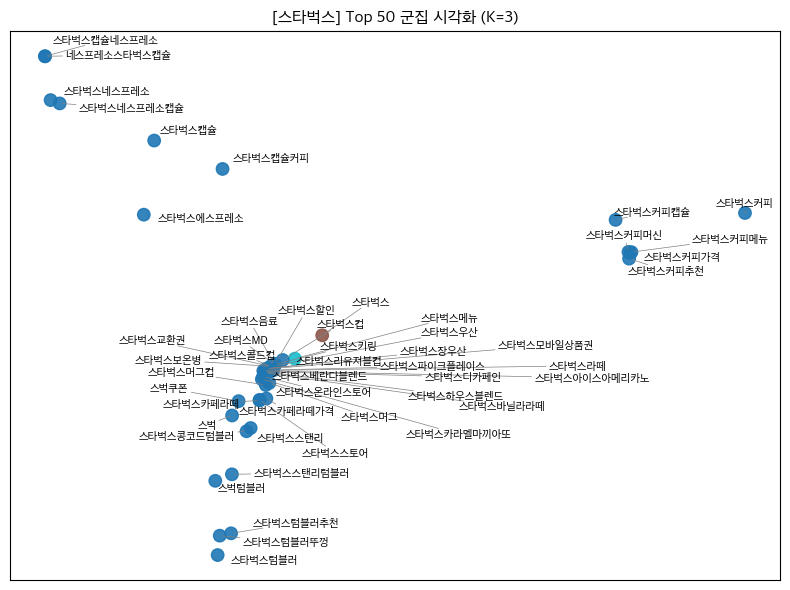

✅ 이미지 저장: 스타벅스_cluster.png

[스타벅스] Top 50 자동 군집화 결과 (K=3)

 - Cluster 0 (총 검색량: 378,070)
relKeyword  totalSearch
   스타벅스텀블러       131400
        스벅        29130
    스타벅스캡슐        18330
    스타벅스우산        13910
스타벅스스탠리텀블러        12580
    스타벅스커피        11620
   스타벅스머그컵        10040
     스벅텀블러         9460
    스타벅스MD         9120
 스타벅스바닐라라떼         9060

 - Cluster 1 (총 검색량: 1,276,400)
relKeyword  totalSearch
      스타벅스      1276400

 - Cluster 2 (총 검색량: 255,000)
relKeyword  totalSearch
    스타벅스메뉴       255000


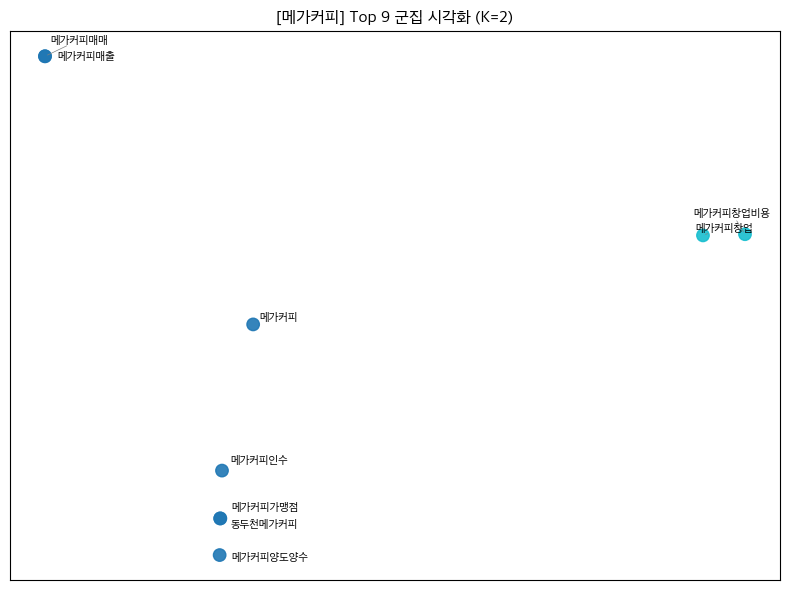

✅ 이미지 저장: 메가커피_cluster.png

[메가커피] Top 9 자동 군집화 결과 (K=2)

 - Cluster 0 (총 검색량: 1,448,880)
relKeyword  totalSearch
      메가커피      1441700
  메가커피양도양수         2820
   메가커피가맹점         1940
    메가커피인수          970
    메가커피매출          660
   동두천메가커피          460
    메가커피매매          330

 - Cluster 1 (총 검색량: 14,740)
relKeyword  totalSearch
  메가커피창업비용        10980
    메가커피창업         3760

✅ 엑셀 저장: brands_clusters_starbucks_megacoffee.xlsx


In [12]:
# -*- coding: utf-8 -*-
# 스타벅스, 메가커피 Top 50 군집 + 시각화 + 엑셀 저장 (adjustText로 라벨 겹침 방지)

import re
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from adjustText import adjust_text

# =========================================
# 0) 설정
# =========================================
INPUT_FILE = "/Users/mac/Python_basic/Python_won/100/01_Basic/coffee_brand_keywords/2.starbucks_mega_top100.xlsx"
TOP_N = 50
MAX_CLUSTERS = 5
BRANDS = ["스타벅스", "메가커피"]  # 분석할 브랜드 리스트

# 브랜드별 패턴(별칭/축약 포함) — 필요시 자유롭게 추가/수정
BRAND_PATTERNS = {
    "스타벅스": [
        r"스타벅스", r"\b스벅\b", r"starbucks", r"스타벅$", r"스\벅"  # 마지막 2개는 여유 패턴
    ],
    "메가커피": [
        r"메가커피", r"메가\s*커피", r"메가MGC커피", r"MGC커피", r"\b메가\b(?=.*커피)"
    ]
}

# 폰트(맥/윈도우 무난 설정)
plt.rcParams['axes.unicode_minus'] = False
for font in ["Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"]:
    plt.rcParams['font.family'] = font
    break

# =========================================
# 1) 데이터 로드 & 전처리
# =========================================
df = pd.read_excel(INPUT_FILE)

# 검색량 합계
for c in ["monthlyPcQcCnt", "monthlyMobileQcCnt"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)
    else:
        df[c] = 0
df["totalSearch"] = df.get("monthlyPcQcCnt", 0) + df.get("monthlyMobileQcCnt", 0)

# 문자열 정리
df["relKeyword"] = df["relKeyword"].astype(str).str.strip()
if "seed" in df.columns:
    df["seed"] = df["seed"].astype(str).str.strip()

# =========================================
# 2) 브랜드 라벨링: seed 우선, 없으면 패턴 매칭
# =========================================
def label_brand(row):
    kw = row["relKeyword"]
    seed_val = row["seed"] if "seed" in row and pd.notna(row["seed"]) else ""
    # seed가 명확하면 seed로 판단
    for brand in BRANDS:
        if brand in seed_val:
            return brand
    # seed가 없거나 애매하면 패턴으로 판단
    for brand, pats in BRAND_PATTERNS.items():
        for p in pats:
            if re.search(p, kw, flags=re.IGNORECASE):
                return brand
    return "기타"

df["brand"] = df.apply(label_brand, axis=1)

# 브랜드별 집계(동일 키워드 합산)
agg = (df.groupby(["brand", "relKeyword"], as_index=False)["totalSearch"].sum())
agg = agg[agg["brand"].isin(BRANDS)].copy()

# =========================================
# 3) strict 필터: '브랜드와 직접 관련된' 키워드만
#    (브랜드명 자체/별칭이 포함된 것만 유지; 주관 최소화)
# =========================================
def strict_brand_filter(brand, kw):
    kw = str(kw)
    pats = BRAND_PATTERNS.get(brand, [])
    return any(re.search(p, kw, flags=re.IGNORECASE) for p in pats)

strict = agg[agg.apply(lambda r: strict_brand_filter(r["brand"], r["relKeyword"]), axis=1)].copy()

# =========================================
# 4) K-means + PCA + 시각화 + 저장
# =========================================
all_results = []  # 엑셀 저장용 누적

def kmeans_plot_brand(df_brand, brand_name, topN=TOP_N, max_clusters=MAX_CLUSTERS):
    df_top = (df_brand.sort_values("totalSearch", ascending=False).head(topN)).reset_index(drop=True)
    if len(df_top) < 6:
        print(f"\n[{brand_name}] 데이터 부족 → 군집 생략 (키워드 {len(df_top)}개)")
        return

    kws = df_top["relKeyword"].astype(str).tolist()
    weights = df_top["totalSearch"].values

    # 문자 n-gram TF-IDF (형태소 없이도 안정)
    vec = TfidfVectorizer(analyzer="char", ngram_range=(2,4), min_df=1)
    X = vec.fit_transform(kws)

    # 클러스터 수 자동(15개당 1클러스터, 2~max_clusters)
    n_clusters = int(min(max_clusters, max(2, len(kws)//15)))
    n_clusters = max(2, n_clusters)

    km = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    labels = km.fit_predict(X, sample_weight=weights)

    # 2D 축소
    coords = PCA(n_components=2, random_state=42).fit_transform(X.toarray())

    # ===== 시각화 =====
    plt.figure(figsize=(8,6))
    plt.scatter(coords[:,0], coords[:,1], c=labels, cmap="tab10", s=80, alpha=0.9)
    texts = []
    for i, txt in enumerate(kws):
        texts.append(plt.text(coords[i,0], coords[i,1], txt, fontsize=8))
    adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))

    plt.title(f"[{brand_name}] Top {len(df_top)} 군집 시각화 (K={n_clusters})")
    plt.xticks([]); plt.yticks([])
    plt.tight_layout()
    out_png = f"{brand_name}_cluster.png"
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"✅ 이미지 저장: {out_png}")

    # ===== 표 정리 =====
    df_top["cluster"] = labels
    df_top["x"] = coords[:,0]
    df_top["y"] = coords[:,1]
    df_top["brand"] = brand_name
    all_results.append(df_top)

    # 콘솔 요약
    print(f"\n[{brand_name}] Top {len(df_top)} 자동 군집화 결과 (K={n_clusters})")
    for c in range(n_clusters):
        grp = (df_top[df_top["cluster"]==c]
               .sort_values("totalSearch", ascending=False)
               .head(10))
        total_grp = int(df_top[df_top["cluster"]==c]["totalSearch"].sum())
        print(f"\n - Cluster {c} (총 검색량: {total_grp:,})")
        print(grp[["relKeyword","totalSearch"]].to_string(index=False))

# =========================================
# 5) 실행: 브랜드별 군집/시각화
# =========================================
for brand in BRANDS:
    df_b = strict[strict["brand"] == brand]
    if not df_b.empty:
        kmeans_plot_brand(df_b, brand_name=brand, topN=TOP_N, max_clusters=MAX_CLUSTERS)
    else:
        print(f"\n[{brand}] 해당 데이터가 없습니다.")

# =========================================
# 6) 엑셀 저장 (브랜드별 TopN + cluster + 좌표)
# =========================================
if all_results:
    final_df = pd.concat(all_results, ignore_index=True)
    out_xlsx = "brands_clusters_starbucks_megacoffee.xlsx"
    final_df.to_excel(out_xlsx, index=False)
    print(f"\n✅ 엑셀 저장: {out_xlsx}")


In [7]:
#스타벅스 사이트 > 메뉴 > 음료 > 카테고리(선택) 데이터 기반으로 마케팅 인사이트 도출
#1) 원하는 카테고리 선택 후 음료 페이지 크롤링 (이름, 사진, 용량, 칼로리)
#2) 크롤링 데이터 엑셀 출력
#3) SQL로 분석해야 하는 내용
#- 카테고리별 평균 칼로리
#- 상품금액과 칼로리 상관관계 분석

from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.action_chains import ActionChains
import time
import re  # 정규 표현식 (숫자만 추출)
from selenium.common.exceptions import NoSuchElementException  # 요소가 없을 때 발생하는 예외 처리
import pandas as pd
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import pymysql  # MySQL 데이터베이스 연결 라이브러리

host = 'localhost'
user = 'root'
password = 'Wonsil929621!@#'
db_name = 'starbucks_db'
charset = 'utf8mb4'
port = 3306

# --- Selenium WebDriver 설정 ---
service = Service(ChromeDriverManager().install())
options = Options()
options.add_argument('--window-size=1920x1080')
options.add_argument('--start-maximized')
options.add_argument('--user-agent=Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/138.0.0.0 Safari/537.36')
options.add_argument('--lang=ko_KR')
driver = webdriver.Chrome(service=service, options=options)

conn = None   # MySQL 연결 객체 초기화
cursor = None # MySQL 커서 객체 초기화

url = "https://www.starbucks.co.kr"
driver.get(url)

menu = driver.find_element(By.CSS_SELECTOR, "li.gnb_nav02")
menu.click()
time.sleep(1)

# 현재 메인 탭 핸들 저장 (새 탭 열고 닫기 위함)
main_window_handle = driver.current_window_handle

drink = driver.find_element(By.CSS_SELECTOR, "li.gnb_sub_ttl > a[href*='drink_list.do']")
drink.click()

driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
time.sleep(1)

# 현재 탭 핸들 저장
main = driver.current_window_handle

# 상품 상세 링크 수집
links = driver.find_elements(By.CSS_SELECTOR, "a.goDrinkView[prod]")
detail_urls = [f"https://www.starbucks.co.kr/menu/drink_view.do?product_cd={a.get_attribute('prod')}"
               for a in links]

print(f"총 {len(detail_urls)}개 링크 수집")

data = []

for idx, url in enumerate(detail_urls, start=1):
    # 새 탭으로 열기
    driver.execute_script("window.open(arguments[0], '_blank');", url)
    driver.switch_to.window(driver.window_handles[-1])

    try:
        # 제품명
        name = driver.find_element(By.CSS_SELECTOR, "div.myAssignZone > h4").text.strip()

        # 영양성분표 존재 확인
        nutrition_exists = driver.find_elements(By.CSS_SELECTOR, "div.product_info_content")
        if not nutrition_exists:
            print(f"{idx}: {name} ▶ 영양성분표 없음 → 패스")
            driver.close()
            driver.switch_to.window(main)
            continue

        # 영양 성분 추출 (없으면 빈 문자열 처리)
        def safe_text(css):
            try:
                return driver.find_element(By.CSS_SELECTOR, css).text.strip()
            except:
                return ""

        kcal     = safe_text("li.kcal dd")
        sodium   = safe_text("li.sodium dd")
        sugar    = safe_text("li.sugars dd")
        protein  = safe_text("li.protein dd")
        fat_sat  = safe_text("li.sat_FAT dd")
        caffeine = safe_text("li.caffeine dd")

        # ✅ 모든 값이 비어 있으면 수집 대상에서 제외
        if all(v == "" for v in (kcal, sodium, sugar, protein, fat_sat, caffeine)):
            print(f"{idx}: {name} ▶ 영양성분 전부 없음 → 패스")
            driver.close()
            driver.switch_to.window(main)
            continue

        row = {
            "제품명": name,
            "1회 제공량 (kcal)": kcal,
            "나트륨 (mg)": sodium,
            "당류 (g)": sugar,
            "단백질 (g)": protein,
            "포화지방 (g)": fat_sat,
            "카페인 (mg)": caffeine
        }
        data.append(row)
        print(f"{idx}: 수집 ▶ {name} | kcal:{kcal} / 나트륨:{sodium} / 당류:{sugar} / 단백질:{protein} / 포화지방:{fat_sat} / 카페인:{caffeine}")

    except Exception as e:
        print(f"{idx} 에러 ▶ {e}")

    driver.close()
    driver.switch_to.window(main)

print(f"\n총 수집 {len(data)}건 완료")

# ===== DB INSERT =====

conn = pymysql.connect(host=host, user=user, password=password,
                       database=db_name, charset=charset, port=port)
cur = conn.cursor()

# 커넥션 직후 한 번만
conn.autocommit(False)
cur.execute("SET SESSION innodb_lock_wait_timeout=50")
cur.execute("SET SESSION TRANSACTION ISOLATION LEVEL READ COMMITTED")

# 전처리 함수
def parse_int(x):
    if x is None: return None
    s = str(x).strip()
    if s in ("", "-"): return None
    s = re.sub(r"[^0-9\.\-]", "", s)  # 숫자/소수점/부호만 남김
    if s in ("", "-", "+"): return None
    try:
        return int(float(s))
    except:
        return None

def parse_float(x):
    if x is None: return None
    s = str(x).strip()
    if s in ("", "-"): return None
    s = re.sub(r"[^0-9\.\-]", "", s)
    if s in ("", "-", "+"): return None
    try:
        return float(s)
    except:
        return None

# rows 생성 (오타 및 괄호 수정)
rows = [
    (
        d.get("제품명") or None,
        parse_int(d.get("1회 제공량 (kcal)")),
        parse_int(d.get("나트륨 (mg)")),
        parse_float(d.get("당류 (g)")),
        parse_float(d.get("단백질 (g)")),
        parse_float(d.get("포화지방 (g)")),
        parse_int(d.get("카페인 (mg)"))
    )
    for d in data
]



sql = """
INSERT INTO starbucks_products
(name, kcal, sodium, sugar, protein, fat_sat, caffeine)
VALUES (%s, %s, %s, %s, %s, %s, %s)
"""

BATCH = 200
total = 0

try:
    for i in range(0, len(rows_ok), BATCH):
        batch = rows[i:i+BATCH]
        try:
            cur.executemany(sql, batch)
            conn.commit()
            total += len(batch)
            print(f"✔ INSERT {total}/{len(rows)}")
        except Exception as e:
            conn.rollback()
            print(f"✖ 배치 {i}-{i+len(batch)} 실패: {e}")
            time.sleep(1.0)
            # 1회 재시도
            cur.executemany(sql, batch)
            conn.commit()
            total += len(batch)
            print(f"↻ 재시도 성공: {total}/{len(rows)}")
    print(f"✅ DB 저장 완료: {total}건 (starbucks_db.starbucks_products)")
finally:
    cur.close()
    conn.close()





총 181개 링크 수집
1: 수집 ▶ 나이트로 바닐라 크림
Nitro Vanilla Cream | kcal:80 / 나트륨:40 / 당류:10 / 단백질:1 / 포화지방:2 / 카페인:232
2: 수집 ▶ 나이트로 콜드 브루
Nitro Cold Brew | kcal:5 / 나트륨:5 / 당류:0 / 단백질:0 / 포화지방:0 / 카페인:245
3: 수집 ▶ 돌체 콜드 브루
Dolce Cold Brew | kcal:220 / 나트륨:80 / 당류:22 / 단백질:6 / 포화지방:6 / 카페인:155
4: 수집 ▶ 리저브 나이트로
Reserve Nitro | kcal:5 / 나트륨:0 / 당류:0 / 단백질:0 / 포화지방:0 / 카페인:190
5: 수집 ▶ 리저브 콜드 브루
Reserve Cold Brew | kcal:5 / 나트륨:0 / 당류:0 / 단백질:0 / 포화지방:0 / 카페인:190
6: 수집 ▶ 막걸리향 크림 콜드 브루
Rice Cream Cold Brew | kcal:300 / 나트륨:65 / 당류:32 / 단백질:3 / 포화지방:13 / 카페인:53
7: 수집 ▶ 민트 콜드 브루
Mint Cold Brew | kcal:100 / 나트륨:0 / 당류:23 / 단백질:0 / 포화지방:0 / 카페인:415
8: 수집 ▶ 바닐라 크림 콜드 브루
Vanilla Cream Cold Brew | kcal:125 / 나트륨:58 / 당류:11 / 단백질:3 / 포화지방:6 / 카페인:155
9: 수집 ▶ 베르가못 콜드 브루
Bergamot Cold Brew | kcal:125 / 나트륨:45 / 당류:22 / 단백질:3 / 포화지방:1.7 / 카페인:90
10: 수집 ▶ 블랙&화이트 콜드 브루
Black&White Cold Brew | kcal:175 / 나트륨:70 / 당류:12 / 단백질:1 / 포화지방:12 / 카페인:190
11: 수집 ▶ 스모크드 콜드 패션드
Smoked Cold Fashioned | kcal:30 / 나트륨:0 / 당류:6 / 단백

In [39]:
import pymysql
# from sqlalchemy import create_engine  # (지금은 안 쓰면 지워도 됨)

host = 'localhost'
user = 'root'
password = 'Wonsil929621!@#'
db_name = 'starbucks_db'
charset = 'utf8mb4'
port = 3306

# 1) DB 미지정으로 서버 연결
#db = pymysql.connect(host=host, user=user, password=password, charset=charset, port=port)
#cursor = db.cursor()

# 2) DB 생성 (★ 실행 누락됐던 부분)
#sql = f"CREATE DATABASE IF NOT EXISTS {db_name};"
#cursor.execute(sql)               # ★ 이 줄이 필요
#db.commit()

#db.close()

# 3) 생성된 DB로 재연결
db = pymysql.connect(host=host, user=user, password=password, database=db_name, charset=charset, port=port)
cursor = db.cursor()
print("starbucks_db 연결 완료")
    
#테이블 생성 

sql = """ 
    CREATE TABLE IF NOT EXISTS starbucks_products (
    id INT AUTO_INCREMENT PRIMARY KEY,
    name VARCHAR(100) NOT NULL,
    kcal INT NOT NULL,
    sodium INT NOT NULL,
    sugar INT NOT NULL,
    protein INT NOT NULL,
    fat_sat INT NOT NULL,
    caffeine INT NOT NULL
    )


"""
cursor.execute(sql)
print("테이블 생성완료")
db.commit()


starbucks_db 연결 완료
테이블 생성완료
